### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [49]:
data.head(10)


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
5,No Urgent Place,Friend(s),Sunny,80,6PM,Restaurant(<20),2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
6,No Urgent Place,Friend(s),Sunny,55,2PM,Carry out & Take away,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
7,No Urgent Place,Kid(s),Sunny,80,10AM,Restaurant(<20),2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
8,No Urgent Place,Kid(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [225]:
missing = data.isnull().sum().sort_values(ascending=False).head(10)
print(missing)

car                     12576
CoffeeHouse               217
Restaurant20To50          189
CarryAway                 151
RestaurantLessThan20      130
Bar                       107
destination                 0
passanger                   0
direction_opp               0
direction_same              0
dtype: int64


3. Decide what to do about your missing data -- drop, replace, other...

In [104]:
print(data[['CoffeeHouse','Restaurant20To50','CarryAway','RestaurantLessThan20','Bar']].isnull().sum())
data_dn = data.dropna(subset = ['CoffeeHouse', 'Restaurant20To50', 'CarryAway', 'RestaurantLessThan20', 'Bar'])
print(data_dn[['CoffeeHouse','Restaurant20To50','CarryAway','RestaurantLessThan20','Bar']].isnull().sum())

CoffeeHouse             217
Restaurant20To50        189
CarryAway               151
RestaurantLessThan20    130
Bar                     107
dtype: int64
CoffeeHouse             0
Restaurant20To50        0
CarryAway               0
RestaurantLessThan20    0
Bar                     0
dtype: int64


4. What proportion of the total observations chose to accept the coupon?



In [41]:
data_dn['Y'].sum() / len(data_dn)

np.float64(0.5693352098683666)

5. Use a bar plot to visualize the `coupon` column.

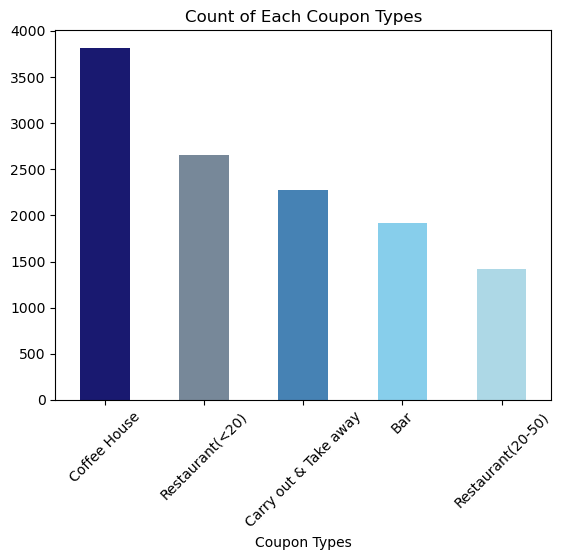

In [ ]:
# Draw bar plot without missing values, and assign different colors to each bar (by coupon types)
data_dn['coupon'].value_counts().plot(kind='bar', color = ['midnightblue', 'lightslategray', 'steelblue', 'skyblue', 'lightblue'])
plt.title('Count of Each Coupon Types')
plt.xlabel('Coupon Types')
plt.xticks(rotation=45)
plt.show()

6. Use a histogram to visualize the temperature column.

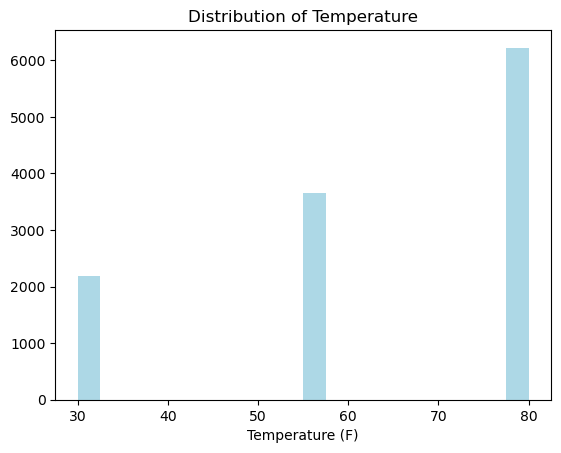

In [ ]:
# Draw histogram of temperature with matplotlib
plt.hist(data_dn['temperature'], bins = 20, color = 'lightblue')
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (F)')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [110]:
data_bar = data_dn[data_dn['coupon'] == 'Bar']
print(data_bar)

           destination  passanger weather  temperature  time coupon  \
24     No Urgent Place  Friend(s)   Sunny           80  10AM    Bar   
35                Home      Alone   Sunny           55   6PM    Bar   
39                Work      Alone   Sunny           55   7AM    Bar   
46     No Urgent Place  Friend(s)   Sunny           80  10AM    Bar   
57                Home      Alone   Sunny           55   6PM    Bar   
...                ...        ...     ...          ...   ...    ...   
12663  No Urgent Place  Friend(s)   Sunny           80  10PM    Bar   
12664  No Urgent Place  Friend(s)   Sunny           55  10PM    Bar   
12667  No Urgent Place      Alone   Rainy           55  10AM    Bar   
12670  No Urgent Place    Partner   Rainy           55   6PM    Bar   
12682             Work      Alone   Snowy           30   7AM    Bar   

      expiration gender age maritalStatus  ...  CoffeeHouse CarryAway  \
24            1d   Male  21        Single  ...        less1       4~8   
3

2. What proportion of bar coupons were accepted?


In [111]:
data_bar['Y'].sum() / len(data_bar)

np.float64(0.41191845269210664)

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [141]:
bar_ac3 = data_bar[data_bar['Bar'].isin(['never', 'less1', '1~3'])]
print(bar_ac3['Y'].sum() / len(bar_ac3))
bar_acm = data_bar[~data_bar['Bar'].isin(['never', 'less1', '1~3'])]
print(bar_acm['Y'].sum() / len(bar_acm))


0.37267441860465117
0.7616580310880829


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [181]:
data_bar['age'] = data_bar['age'].replace({'50plus': 51, 'below21': 20}).astype(int)

cond = (~(data_bar['Bar'].isin(['never', 'less1'])) & (data_bar['age'] > 25))

ab25 = data_bar[cond]['Y'].mean()
print(ab25)
abao = data_bar[~cond]['Y'].mean()
print(abao)


0.6898263027295285
0.33774834437086093


/var/folders/zq/hc0wv4vx2d39rw19163dklhw0000gn/T/ipykernel_16243/551776252.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_bar['age'] = data_bar['age'].replace({'50plus': 51, 'below21': 20}).astype(int)


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [182]:
c1 = (data_bar['Bar'] != 'never') & (data_bar['Bar'] != 'less1')
c2 = (data_bar['passanger'].isin(['Partner', 'Friend(s)']))
c3 = (data_bar['occupation'] != 'Farming Fishing & Forestry')

abo = data_bar[c1 & c2 & c3]['Y'].mean()
print(abo)
aocc = data_bar[~(c1 & c2 & c3)]['Y'].mean()
print(aocc)


0.7142857142857143
0.37877030162412995


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [183]:
g1 = (~(data_bar['Bar'].isin(['never', 'less1'])) & (data_bar['passanger'].isin(['Partner', 'Friend(s)'])) & (data_bar['maritalStatus'] != 'Widowed'))
g2 = (~(data_bar['Bar'].isin(['never', 'less1'])) & (data_bar['age'] < 30))
g3 = (data_bar['RestaurantLessThan20'].isin(['4~8', 'gt8']) & (data_bar['income'].isin(['Less than $12500', '$12500 - $24999', '$25000 - $34799', '$37500 - $49999'])))

a3 = data_bar[ g1 | g2 | g3 ]['Y'].mean()
print(a3)

a3_others = data_bar[~(g1 | g2 | g3)]['Y'].mean()
print(a3_others)



0.5969125214408233
0.3308270676691729


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [ ]:
# Based on the analysis, drivers who accepted the bar coupons are more likely to be frequent visitors of bars or inexpensive restaurants, over the age of 25, and often with partners or friends.
# The acceptance rate was much higher among drivers who went to bars more than a few times per month (0.76 vs 0.37).
# Drivers over the age of 25 who frequently visited bars also had a higher acceptance rate (0.69 vs 0.34).
# In addition, drivers traveling with partners or friends and working outside of farming, fishing, or foresty occupations showed relatively high acceptance rates (0.71 vs 0.38).
# Lastly, drivers who met at least one of the combined conditions in g1, g2, or g3 had a higher acceptance rates (0.60 vs 0.33).

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [ ]:
data_coffee = data_dn[data_dn['coupon'] == 'Coffee House']
print(data_coffee)

           destination  passanger weather  temperature  time        coupon  \
23     No Urgent Place  Friend(s)   Sunny           80  10AM  Coffee House   
26     No Urgent Place  Friend(s)   Sunny           80   2PM  Coffee House   
27     No Urgent Place  Friend(s)   Sunny           80   2PM  Coffee House   
28     No Urgent Place  Friend(s)   Sunny           80   2PM  Coffee House   
30     No Urgent Place  Friend(s)   Sunny           80   6PM  Coffee House   
...                ...        ...     ...          ...   ...           ...   
12656             Home      Alone   Snowy           30  10PM  Coffee House   
12659             Work      Alone   Snowy           30   7AM  Coffee House   
12674             Home      Alone   Rainy           55  10PM  Coffee House   
12675             Home      Alone   Snowy           30  10PM  Coffee House   
12681             Work      Alone   Snowy           30   7AM  Coffee House   

      expiration gender age    maritalStatus  ...  CoffeeHouse 

In [219]:
print(data_coffee['CoffeeHouse'].value_counts(), '\n')

less_coffee = data_coffee[data_coffee['CoffeeHouse'].isin(['never', 'less1'])]
print(less_coffee['Y'].mean())
more_coffee = data_coffee[data_coffee['CoffeeHouse'].isin(['1~3', '4~8', 'gt8'])]
print(more_coffee['Y'].mean())


CoffeeHouse
less1    1052
1~3      1019
never     896
4~8       507
gt8       342
Name: count, dtype: int64 

0.34034907597535935
0.6589935760171306


In [220]:
print(less_coffee.groupby('passanger')['Y'].mean().sort_values(ascending=False).head(), '\n')
print(more_coffee.groupby('passanger')['Y'].mean().sort_values(ascending=False).head())

passanger
Friend(s)    0.430272
Partner      0.421965
Alone        0.285714
Kid(s)       0.261364
Name: Y, dtype: float64 

passanger
Partner      0.779661
Friend(s)    0.764906
Kid(s)       0.647619
Alone        0.587902
Name: Y, dtype: float64


In [223]:
print(less_coffee.groupby('occupation')['Y'].mean().sort_values(ascending=False).head(), '\n')
print(more_coffee.groupby('occupation')['Y'].mean().sort_values(ascending=False).head())

occupation
Building & Grounds Cleaning & Maintenance    0.727273
Healthcare Support                           0.619048
Farming Fishing & Forestry                   0.545455
Transportation & Material Moving             0.530612
Architecture & Engineering                   0.511628
Name: Y, dtype: float64 

occupation
Healthcare Practitioners & Technical    0.900000
Personal Care & Service                 0.888889
Construction & Extraction               0.875000
Production Occupations                  0.857143
Installation Maintenance & Repair       0.807692
Name: Y, dtype: float64
